# Gaussian 2SFCA 의료시설 접근성 — 2026-08-14 09:00 오전 첨두

1km 인구 격자(demand)와 의료시설(supply)의 대중교통 통행시간을 이용해 Gaussian 거리조락
2단계 부양권역법(2SFCA)으로 접근성 지수를 계산한다.

GTFS 스케줄 기반 대중교통망은 A→B와 B→A 통행시간이 다를 수 있어(경로/배차 비대칭),
Step1(의료시설이 origin)과 Step2(격자가 origin)에 방향이 다른 TravelTimeMatrix를 각각 쓴다.

## 파라미터

| 항목 | 값 |
|---|---|
| Demand | 1km 인구 격자, 총인구수(`TOT_POP`) > 0만 사용, 대상 지역 내 6,878개 중 4,987개 |
| Supply | 의료시설, 총의사수(`N_DOCTOR`, 0인 시설은 제외), 대상 지역 20km 버퍼 내 3,487개 |
| Mobility (Step1용) | r5py `TravelTimeMatrix` (`compute_ttm_g2sfca_facility_origin.py`), origin=의료시설 → destination=격자 |
| Mobility (Step2용) | r5py `TravelTimeMatrix` (`compute_ttm_g2sfca.py`), origin=격자 → destination=의료시설 |
| 공통 파라미터 | 2026-08-14(금) 09:00 출발, departure_time_window=3시간, TRANSIT+WALK, max_time=60분 |
| d0 (Gaussian 임계 통행시간) | 60분 |

Gaussian 거리조락함수와 2SFCA 2단계 계산은 아래 형태를 따른다(참고 코드와 동일한 공식):

- **Step 1** (시설별 공급 대비 수요 비율): 의료시설→격자 방향 통행시간으로, 시설로부터 60분
  이내 도달 가능한 모든 격자의 인구를 Gaussian 가중합해 부양인구를 구하고,
  `총의사수 / 부양인구 * 10000`으로 시설별 비율을 계산
- **Step 2** (격자별 최종 접근성): 격자→시설 방향 통행시간으로, 격자로부터 60분 이내 도달
  가능한 모든 시설의 Step 1 비율에 다시 Gaussian 가중치(`gaussian(d_ij)`)를 곱해 합산

In [2]:
import numpy as np

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

TRVL_TIME = 60  # Gaussian 임계 통행시간(d0), 분


def gaussian(dij, d0):
    """Gaussian distance decay function (dij: pandas Series, d0: 임계 통행시간 스칼라)."""
    val = (np.exp(-0.5 * (dij / d0) ** 2) - np.exp(-0.5)) / (1 - np.exp(-0.5))
    return val.where(dij <= d0, 0.0)

## 1. 데이터 로드

In [3]:
demand = gpd.read_file(
    "data/grid_1km_population_daegugyeongbuk/grid_1km_population_daegugyeongbuk.shp"
).set_index("GRID_CD")
n_before = len(demand)
demand = demand[demand["TOT_POP"] > 0].copy()
print(f"총인구수=0 격자 제외: {n_before - len(demand)}개 (제외 후 {len(demand)}개 유지)")
print(f"demand(1km 격자): {len(demand)}개, 총인구수 합계: {demand['TOT_POP'].sum():,}명")

supply = gpd.read_file("data/g2sfca_20260814_0900/facilities_supply.gpkg").set_index("id")
print(f"supply(의료시설, 20km 버퍼): {len(supply)}개, 총의사수 합계: {supply['N_DOCTOR'].sum():,}명")

# Step1용: 의료시설(origin) -> 격자(destination)
mobility_f2g = pd.read_csv("data/g2sfca_20260814_0900/mobility_facility_to_grid.csv")
print(f"mobility_f2g(시설→격자, 60분 이내): {len(mobility_f2g):,}행")

# Step2용: 격자(origin) -> 의료시설(destination)
mobility_g2f = pd.read_csv("data/g2sfca_20260814_0900/mobility_1km_grid_facility.csv")
print(f"mobility_g2f(격자→시설, 60분 이내): {len(mobility_g2f):,}행")
mobility_f2g.head()

총인구수=0 격자 제외: 1891개 (제외 후 4987개 유지)
demand(1km 격자): 4987개, 총인구수 합계: 3,538,987명
supply(의료시설, 20km 버퍼): 3487개, 총의사수 합계: 7,078명
mobility_f2g(시설→격자, 60분 이내): 516,999행
mobility_g2f(격자→시설, 60분 이내): 519,718행


,FAC_ID,GRID_ID,TT_MIN
0,F0,라마8663,58.0
1,F0,라마8762,59.0
2,F0,라마8956,58.0
3,F0,라마8961,59.0
4,F0,라마8962,58.0


## 2. Step 1 — 시설별 공급 대비 수요 비율

의료시설→격자 방향 통행시간으로, 각 시설로부터 60분 이내 도달 가능한 모든 격자의 인구를 Gaussian 가중합해 부양인구를 구하고, `총의사수 / 부양인구`으로 시설별 비율을 계산한다. 부양인구가 0(60분 내 도달 가능한 격자가 하나도 없음)이면 비율은 0으로 둔다.

In [4]:
mob_pop = mobility_f2g.merge(demand[["TOT_POP"]], left_on="GRID_ID", right_index=True)
mob_pop["decay"] = gaussian(mob_pop["TT_MIN"], TRVL_TIME)
mob_pop["weighted_pop"] = mob_pop["TOT_POP"] * mob_pop["decay"]

catchment_pop = mob_pop.groupby("FAC_ID")["weighted_pop"].sum()
catchment_pop = catchment_pop.reindex(supply.index).fillna(0.0)

step1 = pd.Series(0.0, index=supply.index, name="step1")
has_catchment = catchment_pop > 0
step1.loc[has_catchment] = supply.loc[has_catchment, "N_DOCTOR"] / catchment_pop.loc[has_catchment]

print(f"부양인구가 0인(60분 내 도달 격자 없음) 시설: {(~has_catchment).sum()}개 / {len(supply)}개")
step1.describe()

부양인구가 0인(60분 내 도달 격자 없음) 시설: 637개 / 3487개


count    3.487000e+03
mean     2.788656e-05
std      3.719013e-04
min      0.000000e+00
25%      8.399168e-07
50%      1.317327e-06
75%      3.522628e-06
max      1.762308e-02
Name: step1, dtype: float64

## 3. Step 2 — 격자별 최종 접근성 지수

격자→시설 방향 통행시간으로, 각 격자에서 60분 이내 도달 가능한 모든 시설의 Step 1 비율에 다시 Gaussian 가중치를 곱해 합산한다.

In [5]:
mob_acc = mobility_g2f.merge(step1.rename("step1"), left_on="FAC_ID", right_index=True)
mob_acc["decay"] = gaussian(mob_acc["TT_MIN"], TRVL_TIME)
mob_acc["weighted_acc"] = mob_acc["step1"] * mob_acc["decay"]

step2 = mob_acc.groupby("GRID_ID")["weighted_acc"].sum()
step2 = step2.reindex(demand.index).fillna(0.0)

acc = demand.copy()
acc["G2SFCA"] = step2
print(f"60분 내 도달 가능한 시설이 하나도 없는(접근성 0) 격자: {(acc['G2SFCA'] == 0).sum()}개 / {len(acc)}개")
acc["G2SFCA"].describe()

60분 내 도달 가능한 시설이 하나도 없는(접근성 0) 격자: 3675개 / 4987개


count    4987.000000
mean        0.000230
std         0.000660
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000009
max         0.017617
Name: G2SFCA, dtype: float64

## 4. 저장

In [6]:
import os

out_dir = "data/g2sfca_20260814_0900"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/g2sfca_accessibility_60min.shp"

acc.reset_index()[["GRID_CD", "TOT_POP", "G2SFCA", "geometry"]].to_file(out_path, encoding="utf-8")
print("저장 완료:", out_path)

저장 완료: data/g2sfca_20260814_0900/g2sfca_accessibility_60min.shp


## 5. 시각화

/Users/chaelyn/miniforge3/envs/r5py/lib/python3.13/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 6 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


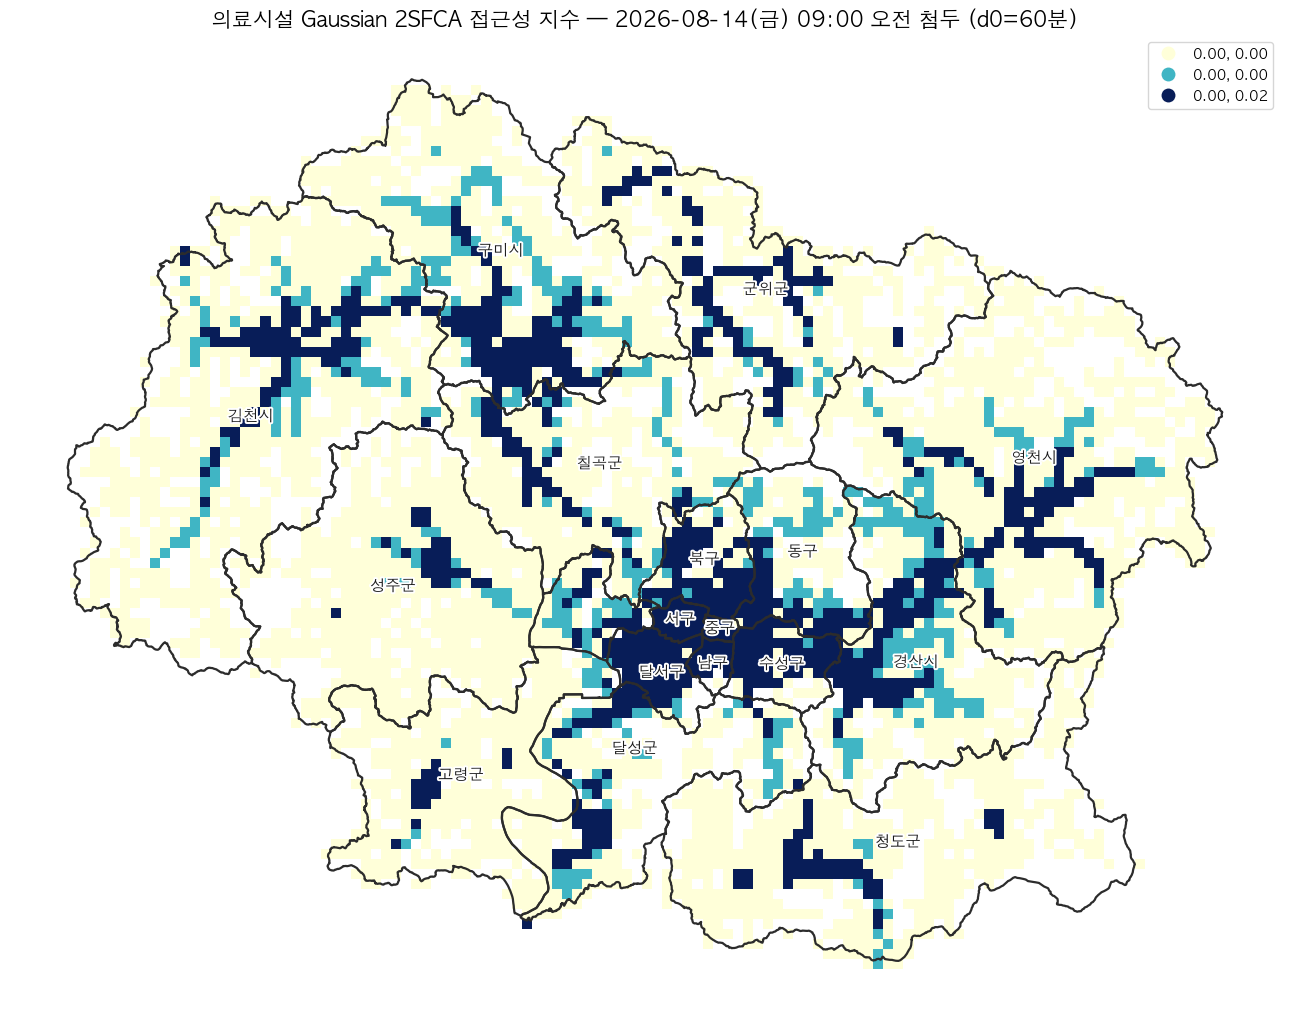

In [7]:
sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")
target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",
    "37050", "37030", "37070", "37100", "37560", "37570", "37580", "37590",
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].to_crs(acc.crs)

fig, ax = plt.subplots(figsize=(13, 13), facecolor="white")

acc.plot(
    ax=ax, column="G2SFCA", cmap="YlGnBu", scheme="quantiles", k=6,
    legend=True, edgecolor="none", zorder=1,
)
target_sigungu.boundary.plot(ax=ax, color="#2c2c2c", linewidth=1.6, zorder=2)
for _, row in target_sigungu.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
        fontsize=11, fontweight="bold", color="#1a1a1a", zorder=3,
        path_effects=[pe.withStroke(linewidth=2.8, foreground="white")],
    )

ax.set_title("의료시설 Gaussian 2SFCA 접근성 지수 — 2026-08-14(금) 09:00 오전 첨두 (d0=60분)",
             fontsize=15, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/g2sfca_20260814_0900/g2sfca_map_60min.png", dpi=200, facecolor="white")
plt.show()